In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Inbuilt boston dataset using sklearn package
from sklearn.datasets import load_boston

In [2]:
boston = load_boston()
boston

{'DESCR': ".. _boston_dataset:\n\nBoston house prices dataset\n---------------------------\n\n**Data Set Characteristics:**  \n\n    :Number of Instances: 506 \n\n    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.\n\n    :Attribute Information (in order):\n        - CRIM     per capita crime rate by town\n        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.\n        - INDUS    proportion of non-retail business acres per town\n        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)\n        - NOX      nitric oxides concentration (parts per 10 million)\n        - RM       average number of rooms per dwelling\n        - AGE      proportion of owner-occupied units built prior to 1940\n        - DIS      weighted distances to five Boston employment centres\n        - RAD      index of accessibility to radial highways\n        - TAX      full-value property-tax rate p

In [3]:
# Converting Array Format of Data into DataFrame
boston_df = pd.DataFrame(boston.data, columns = boston.feature_names)
boston_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [4]:
# Add MEDV Column to boston_df dataset
boston_df['MEDV'] = boston.target

In [5]:
display(boston_df)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


Data Manipulation


In [6]:
boston_df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


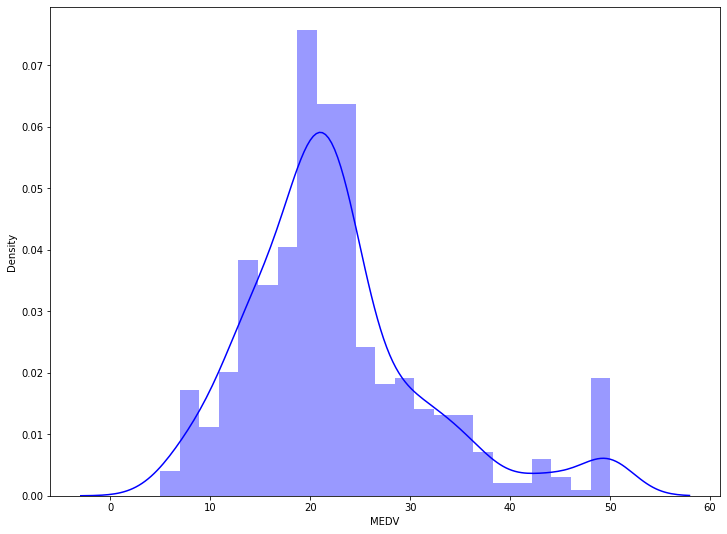

In [7]:
plt.figure(figsize=(12,9))
sns.distplot(boston_df['MEDV'], color = 'blue')
plt.show()

Feature Selection

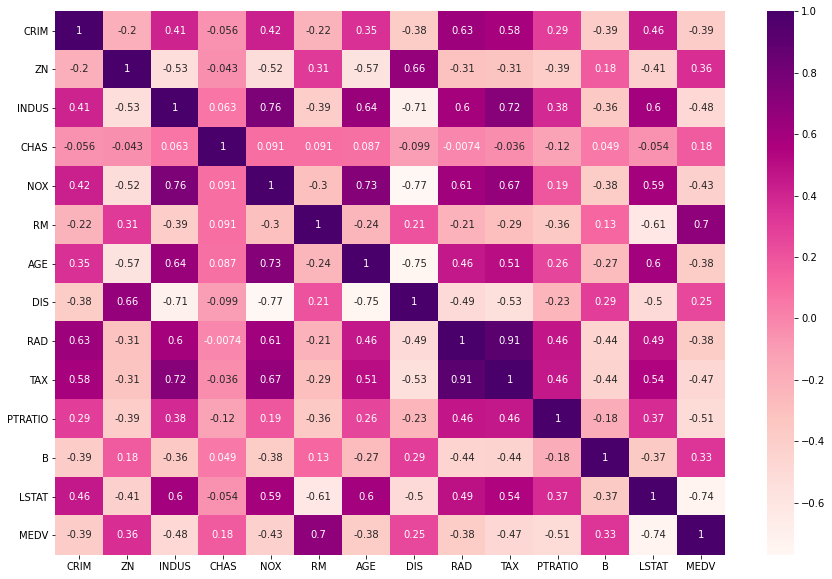

In [8]:
plt.figure(figsize = (15,10))
sns.heatmap(boston_df.corr(), annot = True, cmap = 'RdPu')
plt.show()

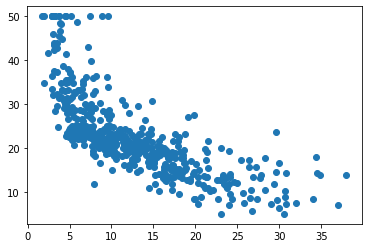

In [9]:
# Muti-Collinearity is Correlation b/w features . Value of correlation must not be >= 0.85 or -0.85
plt.scatter(boston_df['LSTAT'], boston_df['MEDV'])

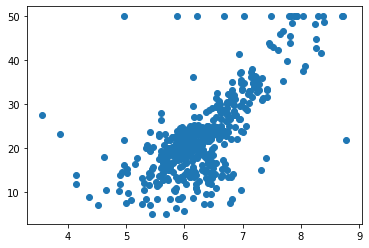

In [10]:
plt.scatter(boston_df['RM'], boston_df['MEDV'])

In [11]:
X = boston_df.drop(['MEDV', 'RAD', 'CHAS'], axis = 1)
y = boston_df['MEDV']

Data Preprocessing

In [12]:
# Scaling - Preprocessing to convert different range of data into (0,1) range
from sklearn.preprocessing import MinMaxScaler
# scaling multiple range of data into (0,1) range 
scaler = MinMaxScaler(feature_range = (0,1))
X_scaled = scaler.fit_transform(X)

Cross Validation
Spliting data into training and testing

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 3)

Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression(normalize = True)

In [15]:
# fit() means training of LR model
lin_reg.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=True)

In [16]:
# Accuracy of Testing
lin_reg.score(X_test, y_test)

0.7911762294960485

In [17]:
yhat = lin_reg.predict(X_test)

In [18]:
# r2_Score, mean squared error, mean absolute error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Mean Absolute Error: ", mean_absolute_error(y_test, yhat))
print("Mean Squared Error: ", mean_squared_error(y_test, yhat))
print("r2 Score: ", r2_score(y_test, yhat))
import numpy as np
print("Root Mean Squared Error: ", np.sqrt(mean_squared_error(y_test, yhat)))

Mean Absolute Error:  3.088869510376244
Mean Squared Error:  17.281169981502263
r2 Score:  0.7911762294960485
Root Mean Squared Error:  4.157062662686511


In [19]:
lin_reg.coef_

array([ -7.82282805,   3.95869278,  -2.84332894,  -5.73104406,
        21.13787222,  -1.13479636, -16.30331391,   1.20345072,
        -7.81790274,   3.7274394 , -18.13628628])

In [20]:
lin_reg.intercept_

25.75092520304186

In [21]:
# Predicting new value
X = [[0.00632,	18.0,	7.31,	0.438,	6.575,	75.2,	4.0900,	286.0,	21.3,	396.90,	4.98]]
X_scaled_new = scaler.transform(X)
lin_reg.predict(X_scaled_new)

array([27.19053795])